In [1]:
# standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# load data
fraud_df = pd.read_csv('../data/creditcard.csv')

# recreate engineered columns from EDA
fraud_df['Amount_log'] = np.log1p(fraud_df['Amount'])
fraud_df['Hour'] = (fraud_df['Time'] / 3600 % 24).astype(int)

print(f"Data loaded: {fraud_df.shape}")
print("Columns:", fraud_df.columns.tolist())

Data loaded: (284807, 33)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class', 'Amount_log', 'Hour']


In [4]:
# sort by time — critical first step for any time series work
# ensures we are always looking at transactions in the order they happened
fraud_df = fraud_df.sort_values('Time').reset_index(drop=True)

# split into 48 hourly buckets
fraud_df['Hour_elapsed'] = (fraud_df['Time'] / 3600).astype(int)

# count fraud and legitimate per hour elapsed
hourly_counts = fraud_df.groupby('Hour_elapsed')['Class'].agg(['sum', 'count'])
hourly_counts.columns = ['fraud_count', 'total_count']
hourly_counts['legit_count'] = hourly_counts['total_count'] - hourly_counts['fraud_count']
hourly_counts['fraud_rate'] = hourly_counts['fraud_count'] / hourly_counts['total_count'] * 100

print(hourly_counts)

              fraud_count  total_count  legit_count  fraud_rate
Hour_elapsed                                                   
0                       2         3963         3961        0.05
1                       2         2217         2215        0.09
2                      21         1576         1555        1.33
3                      13         1821         1808        0.71
4                       6         1082         1076        0.55
5                      11         1681         1670        0.65
6                       3         1831         1828        0.16
7                      23         3368         3345        0.68
8                       5         5179         5174        0.10
9                      15         7878         7863        0.19
10                      2         8288         8286        0.02
11                     43         8517         8474        0.50
12                      9         7732         7723        0.12
13                      9         7585  

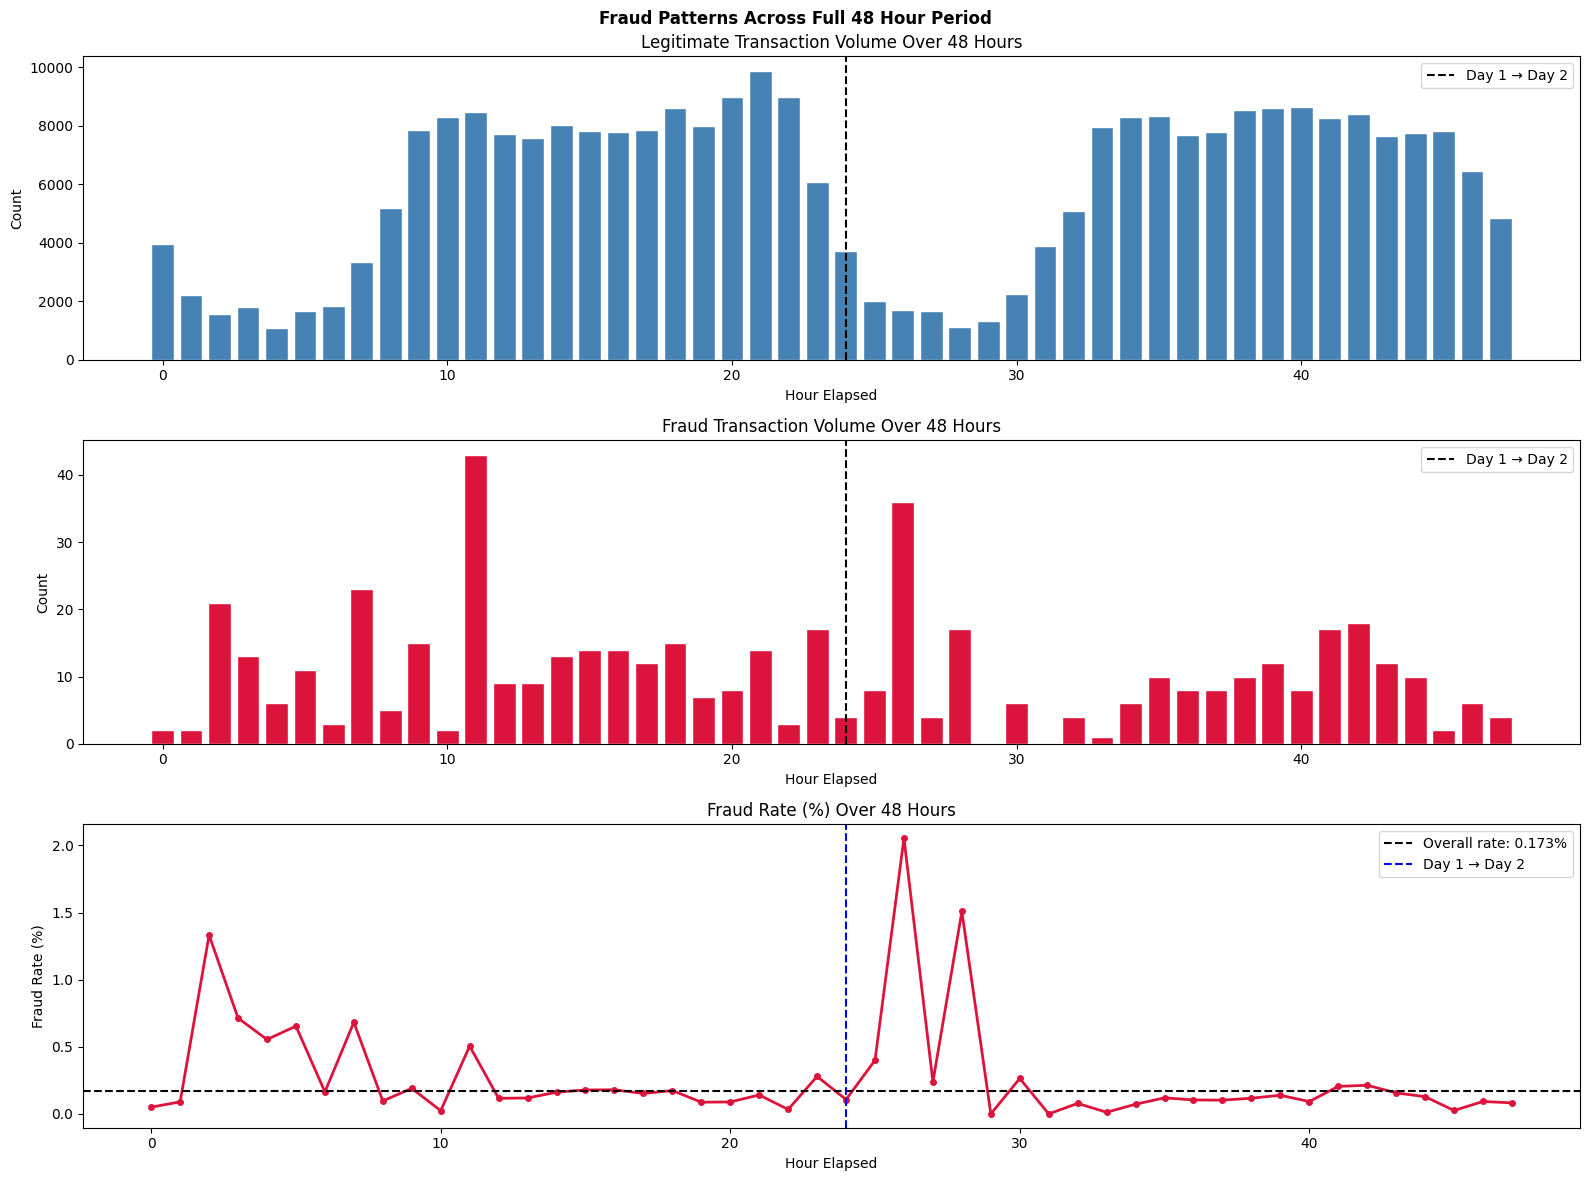

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# plot 1 — legitimate transaction volume over 48 hours
axes[0].bar(hourly_counts.index, hourly_counts['legit_count'], 
            color='steelblue', edgecolor='white', width=0.8)
axes[0].set_title('Legitimate Transaction Volume Over 48 Hours')
axes[0].set_xlabel('Hour Elapsed')
axes[0].set_ylabel('Count')
axes[0].axvline(x=24, color='black', linestyle='--', label='Day 1 → Day 2')
axes[0].legend()

# plot 2 — fraud transaction volume over 48 hours
axes[1].bar(hourly_counts.index, hourly_counts['fraud_count'], 
            color='crimson', edgecolor='white', width=0.8)
axes[1].set_title('Fraud Transaction Volume Over 48 Hours')
axes[1].set_xlabel('Hour Elapsed')
axes[1].set_ylabel('Count')
axes[1].axvline(x=24, color='black', linestyle='--', label='Day 1 → Day 2')
axes[1].legend()

# plot 3 — rolling fraud rate over 48 hours
axes[2].plot(hourly_counts.index, hourly_counts['fraud_rate'], 
             color='crimson', linewidth=2, marker='o', markersize=4)
axes[2].axhline(y=fraud_df['Class'].mean()*100, color='black', 
                linestyle='--', label=f'Overall rate: {fraud_df["Class"].mean()*100:.3f}%')
axes[2].axvline(x=24, color='blue', linestyle='--', label='Day 1 → Day 2')
axes[2].set_title('Fraud Rate (%) Over 48 Hours')
axes[2].set_xlabel('Hour Elapsed')
axes[2].set_ylabel('Fraud Rate (%)')
axes[2].legend()

plt.suptitle('Fraud Patterns Across Full 48 Hour Period', fontweight='bold')
plt.tight_layout()
plt.show()

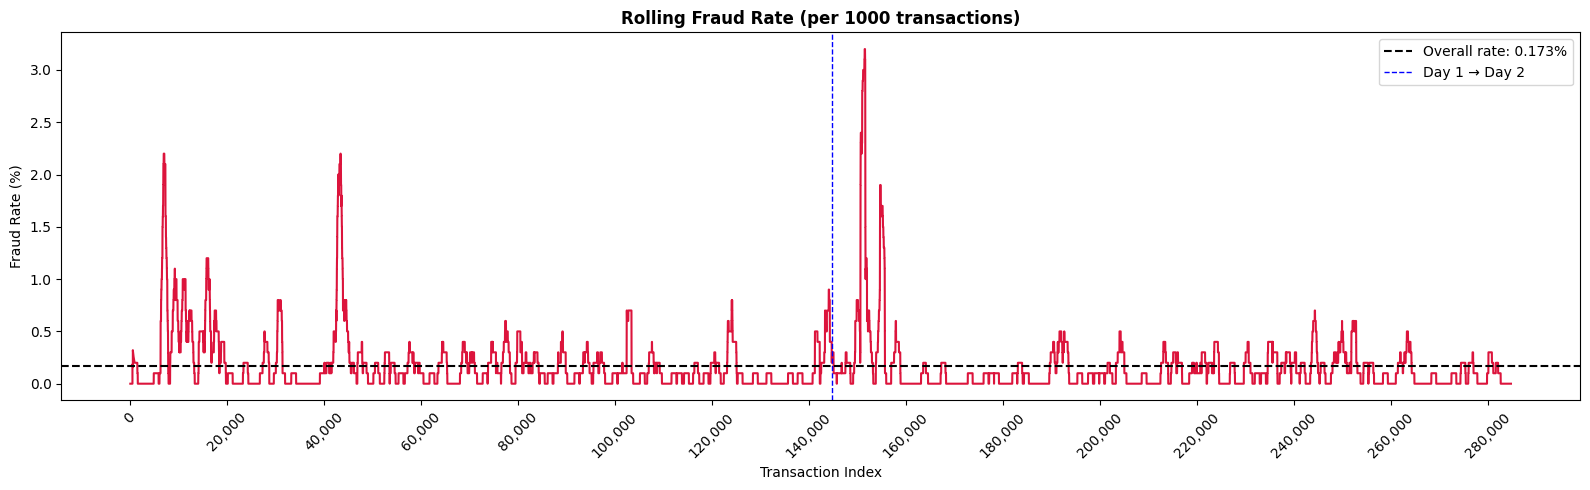

Highest fraud rate spike at transaction: 151,519
Time elapsed: 26.6 hours
Fraud rate at spike: 3.200%


In [7]:
# rolling fraud rate — smoothed view of how fraud evolves over time
# window=1000 means we look at every 1000 transactions at a time
fraud_df_sorted = fraud_df.sort_values('Time').reset_index(drop=True)

# rolling mean of Class column = rolling fraud rate
fraud_df_sorted['rolling_fraud_rate'] = (
    fraud_df_sorted['Class']
    .rolling(window=1000, min_periods=100)
    .mean() * 100
)

plt.figure(figsize=(16, 5))
plt.plot(fraud_df_sorted.index, fraud_df_sorted['rolling_fraud_rate'], 
         color='crimson', linewidth=1.5)
plt.axhline(y=fraud_df['Class'].mean()*100, color='black', 
            linestyle='--', label=f'Overall rate: {fraud_df["Class"].mean()*100:.3f}%')

# add day separator at correct transaction index
day2_start = fraud_df_sorted[fraud_df_sorted['Hour_elapsed'] >= 24].index[0]
plt.axvline(x=day2_start, color='blue', linestyle='--', linewidth=1, label='Day 1 → Day 2')

# readable x axis ticks
plt.xticks(range(0, 284807, 20000), 
           [f'{x:,}' for x in range(0, 284807, 20000)], rotation=45)

plt.title('Rolling Fraud Rate (per 1000 transactions)', fontweight='bold')
plt.xlabel('Transaction Index')
plt.ylabel('Fraud Rate (%)')
plt.legend()
plt.tight_layout()
plt.show()

# find where the highest spike is
max_idx = fraud_df_sorted['rolling_fraud_rate'].idxmax()
print(f"Highest fraud rate spike at transaction: {max_idx:,}")
print(f"Time elapsed: {fraud_df_sorted.loc[max_idx, 'Time']/3600:.1f} hours")
print(f"Fraud rate at spike: {fraud_df_sorted.loc[max_idx, 'rolling_fraud_rate']:.3f}%")

In [ ]:
from sklearn.model_selection import train_test_split
train_random, test_random = train_test_split(fraud_df_sorted, test_size= 0.2, random_state= 42)


split_idx = int(len(fraud_df_sorted)*0.8)
train_time =fraud_df_sorted.iloc[:split_idx]
test_time= fraud_df_sorted.iloc[split_idx:]
print("RANDOM SPLIT (WRONG):")
print(f"Train fraud rate: {train_random['Class'].mean()*100:.3f}%")
print(f"Test fraud rate:  {test_random['Class'].mean()*100:.3f}%")

print("\nTIME-BASED SPLIT (CORRECT):")
print(f"Train fraud rate: {train_time['Class'].mean()*100:.3f}%")
print(f"Test fraud rate:  {test_time['Class'].mean()*100:.3f}%")


print("\nTime range - Train:", 
      f"{train_time['Time'].min()/3600:.1f}h to {train_time['Time'].max()/3600:.1f}h")
print("Time range - Test:", 
      f"{test_time['Time'].min()/3600:.1f}h to {test_time['Time'].max()/3600:.1f}%")



RANDOM SPLIT (WRONG):
Train fraud rate: 0.173%
Test fraud rate:  0.172%

TIME-BASED SPLIT (CORRECT):
Train fraud rate: 0.183%
Test fraud rate:  0.132%

Time range - Train: 0.0h to 40.3h
Time range - Test: 40.3h to 48.0%


In [12]:
print("\nTime range - Train:", 
      f"{train_random['Time'].min()/3600:.1f}h to {train_random['Time'].max()/3600:.1f}h")
print("Time range - Test:", 
      f"{test_random['Time'].min()/3600:.1f}h to {test_random['Time'].max()/3600:.1f}%")



Time range - Train: 0.0h to 48.0h
Time range - Test: 0.0h to 48.0%


In [16]:

# 1. transaction count in last 100 transactions (velocity)
fraud_df_sorted['rolling_txn_count'] =(
    fraud_df_sorted['Amount']
    .rolling(window=100, min_periods=1)
    .count()
)


# 2. rolling average amount in last 100 transactions
fraud_df_sorted['rolling_avg_amount'] = (
    fraud_df_sorted['Amount']
    .rolling(window=100, min_periods=1)
    .mean()
)


# 3. rolling std of amount — measures how erratic recent amounts are
# high std = amounts jumping around = suspicious
fraud_df_sorted['rolling_std_amount'] =(
    fraud_df_sorted['Amount']
    .rolling(window=100, min_periods=1)
    .std()
)

# 4. rolling fraud density — how much fraud in last 100 transactions
fraud_df_sorted['rolling_fraud_density']=(
    fraud_df_sorted['Class']
    .rolling(window=100, min_periods=1)
    .mean()*100
)

print("New velocity features created:")
print(fraud_df_sorted[['Time', 'Amount', 'Class', 
                         'rolling_avg_amount',
                         'rolling_std_amount',
                         'rolling_fraud_density']].head(5))

New velocity features created:
   Time  Amount  Class  rolling_avg_amount  rolling_std_amount  \
0  0.00  149.62      0              149.62                 NaN   
1  0.00    2.69      0               76.16              103.90   
2  1.00  378.66      0              176.99              189.47   
3  1.00  123.50      0              163.62              157.00   
4  2.00   69.99      0              144.89              142.27   

   rolling_fraud_density  
0                   0.00  
1                   0.00  
2                   0.00  
3                   0.00  
4                   0.00  


In [17]:
print(fraud_df_sorted[fraud_df_sorted['rolling_fraud_density'] > 0][
    ['Time', 'Amount', 'Class', 'rolling_fraud_density']].head(10))

      Time  Amount  Class  rolling_fraud_density
541 406.00    0.00      1                   1.00
542 406.00   46.68      0                   1.00
543 407.00  146.25      0                   1.00
544 408.00    7.30      0                   1.00
545 409.00    0.77      0                   1.00
546 409.00   72.00      0                   1.00
547 410.00   56.09      0                   1.00
548 410.00   39.77      0                   1.00
549 410.00    0.89      0                   1.00
550 411.00  235.70      0                   1.00


In [ ]:
# check where fraud density becomes non-zero
